In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from scipy import stats
from sklearn import metrics
from sklearn.model_selection import cross_val_score
import optuna
from sklearn.metrics import precision_score, recall_score, roc_auc_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

C:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_excel('income_est.xlsx')
data

,account,age,amount,balance,card_present_flag,customer_id,date,first_name,gender,latitude,...,txn_description,bin_age,year,month,day,hour,minute,dow,payment_period,annual_salary
0,ACC-1598451071,26,16.25,35.39,1.0,CUS-2487424745,2018-08-01,Diana,F,-27.95,...,POS,20-30,2018,8,1,1,1,Wednesday,7,52856
1,ACC-1598451071,26,14.19,21.20,0.0,CUS-2487424745,2018-08-01,Diana,F,-27.95,...,SALES-POS,20-30,2018,8,1,1,13,Wednesday,7,52856
2,ACC-1598451071,26,3.25,17.95,1.0,CUS-2487424745,2018-08-01,Diana,F,-27.95,...,SALES-POS,20-30,2018,8,1,1,51,Wednesday,7,52856
3,ACC-1598451071,26,14.10,3.85,1.0,CUS-2487424745,2018-08-01,Diana,F,-27.95,...,POS,20-30,2018,8,1,8,9,Wednesday,7,52856
4,ACC-1598451071,26,10.67,1006.85,1.0,CUS-2487424745,2018-08-01,Diana,F,-27.95,...,POS,20-30,2018,8,1,18,19,Wednesday,7,52856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12038,ACC-2153562714,24,3712.56,9707.77,NaN,CUS-423725039,2018-10-24,Linda,F,-31.88,...,PAY/SALARY,20-30,2018,10,24,14,0,Wednesday,30,45169
12039,ACC-1217063613,27,4863.62,4863.86,NaN,CUS-1739931018,2018-09-26,Kimberly,F,-37.82,...,PAY/SALARY,20-30,2018,9,26,13,0,Wednesday,30,59174
12040,ACC-1217063613,27,4863.62,8905.77,NaN,CUS-1739931018,2018-10-26,Kimberly,F,-37.82,...,PAY/SALARY,20-30,2018,10,26,13,0,Friday,30,59174
12041,ACC-3100725361,25,6107.23,6111.57,NaN,CUS-2178051368,2018-09-26,Ronald,M,-17.03,...,PAY/SALARY,20-30,2018,9,26,15,0,Wednesday,30,74305


In [3]:
agg_features = data.groupby('customer_id').agg(
    avg_balance=('balance', 'mean'),
    max_spent=('amount', 'max'),
    avg_spent=('amount', 'mean'),
    txn_count=('transaction_id', 'count')
).reset_index()


credit_totals = data[data['movement'] == 'credit'].groupby('customer_id')['amount'].sum().reset_index(name='total_credit')
debit_totals = data[data['movement'] == 'debit'].groupby('customer_id')['amount'].sum().reset_index(name='total_debit')
salary_totals = data[data['txn_description'] == 'PAY/SALARY'].groupby('customer_id')['amount'].sum().reset_index(name='total_salary_recorded')


data = data.merge(agg_features, on='customer_id', how='left')
data = data.merge(credit_totals, on='customer_id', how='left')
data = data.merge(debit_totals, on='customer_id', how='left')
data = data.merge(salary_totals, on='customer_id', how='left')


# fill_cols = ['total_credit', 'total_debit', 'total_salary_recorded']
# data[fill_cols] = data[fill_cols].fillna(0)

# data.drop_duplicates(subset='customer_id', inplace= True)


print(data.columns)

Index(['account', 'age', 'amount', 'balance', 'card_present_flag',
       'customer_id', 'date', 'first_name', 'gender', 'latitude', 'longitude',
       'merchant_code', 'merchant_id', 'merchant_state', 'merchant_suburb',
       'movement', 'status', 'transaction_id', 'txn_description', 'bin_age',
       'year', 'month', 'day', 'hour', 'minute', 'dow', 'payment_period',
       'annual_salary', 'avg_balance', 'max_spent', 'avg_spent', 'txn_count',
       'total_credit', 'total_debit', 'total_salary_recorded'],
      dtype='str')


In [4]:
data.describe(include = 'all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
account,12043,100,ACC-1598451071,578,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,12043.0,NaN,NaN,NaN,30.58233,10.046343,18.0,22.0,28.0,38.0,78.0
amount,12043.0,NaN,NaN,NaN,187.933588,592.599934,0.1,16.0,29.0,53.655,8835.98
balance,12043.0,NaN,NaN,NaN,14704.195553,31503.722652,0.24,3158.585,6432.01,12465.945,267128.52
card_present_flag,7717.0,NaN,NaN,NaN,0.802644,0.398029,0.0,1.0,1.0,1.0,1.0
customer_id,12043,100,CUS-2487424745,578,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,12043,91,2018-09-28,174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_name,12043,80,Michael,746,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,12043,2,M,6285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,12043.0,NaN,NaN,NaN,-38.164347,54.622791,-573.0,-37.7,-33.89,-30.75,-12.37


In [5]:
df_customers = data.drop_duplicates(subset='customer_id').copy()
df_customers['merchant_state'] = df_customers['merchant_state'].fillna('Unknown')
df_customers['card_present_flag'] = df_customers['card_present_flag'].fillna(0)

df_customers = df_customers.drop(['total_salary_recorded', 'total_credit'], axis=1)

In [6]:
data.drop(['account','customer_id', 'first_name', 'merchant_id', 'merchant_suburb', 'transaction_id', 'merchant_code'], axis=1, inplace= True)
df_customers.drop(['account','customer_id', 'first_name', 'merchant_id', 'merchant_suburb', 'transaction_id', 'merchant_code'], axis=1, inplace= True)
data.isnull().sum()

age                         0
amount                      0
balance                     0
card_present_flag        4326
date                        0
gender                      0
latitude                    0
longitude                   0
merchant_state           4326
movement                    0
status                      0
txn_description             0
bin_age                     0
year                        0
month                       0
day                         0
hour                        0
minute                      0
dow                         0
payment_period              0
annual_salary               0
avg_balance                 0
max_spent                   0
avg_spent                   0
txn_count                   0
total_credit                0
total_debit                 0
total_salary_recorded       0
dtype: int64

In [7]:
data['card_present_flag'].value_counts()

card_present_flag
1.0    6194
0.0    1523
Name: count, dtype: int64

In [8]:
data_linear_knn = data.copy()
data_rf = df_customers.copy()
data_xgb_lgbm_cb = df_customers.copy()
data_cat_trees = df_customers.copy()

# Linear and KNN Pre-Processing

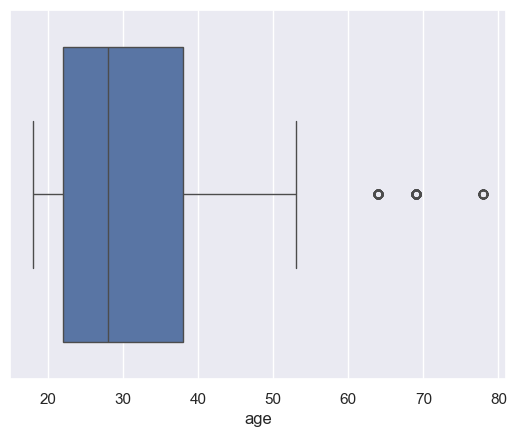

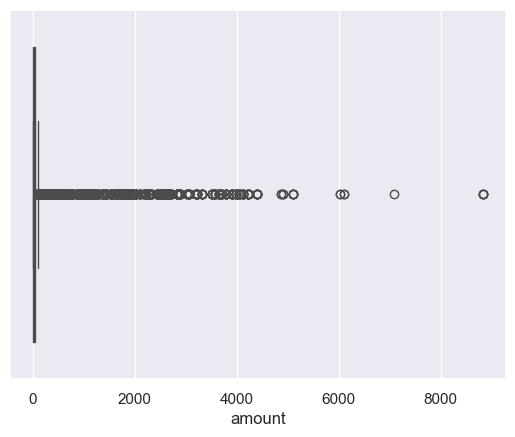

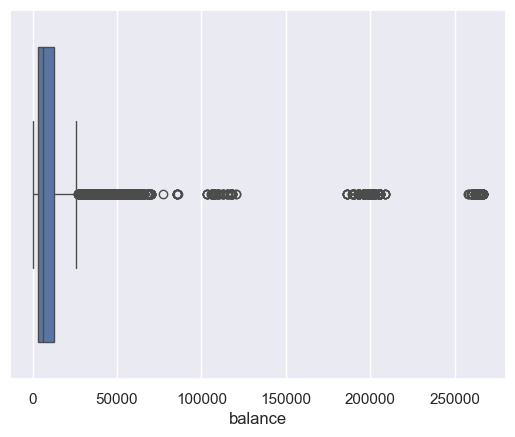

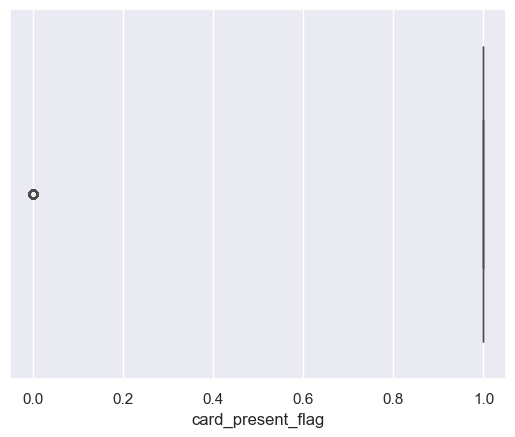

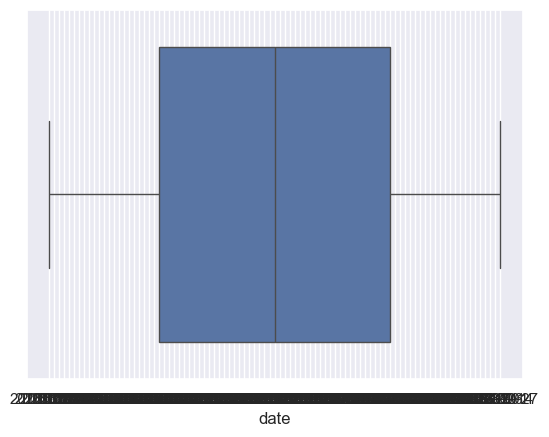

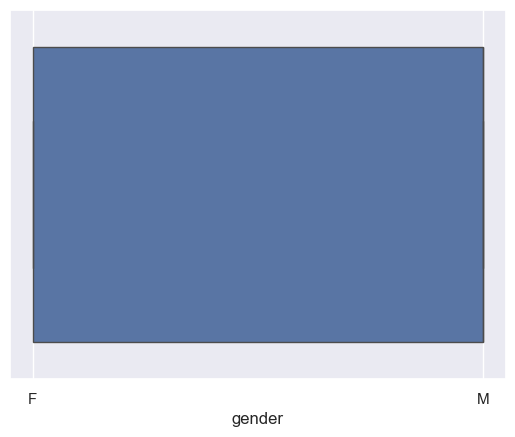

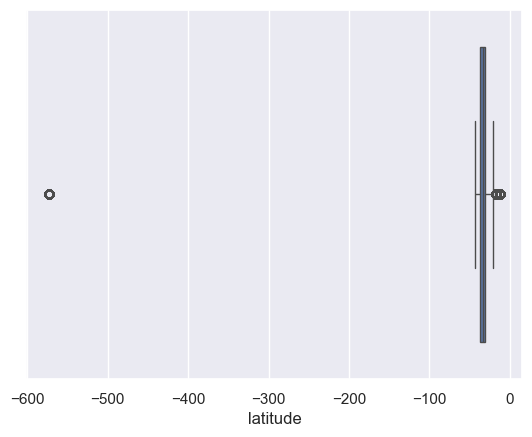

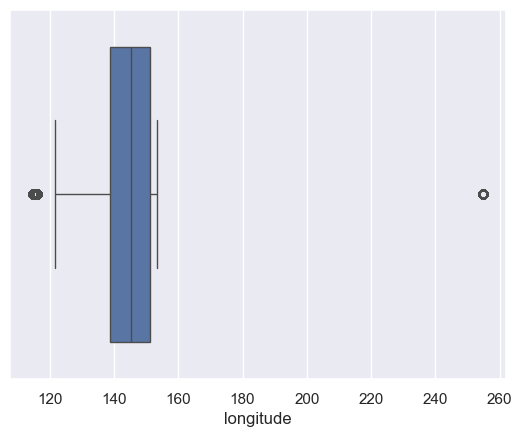

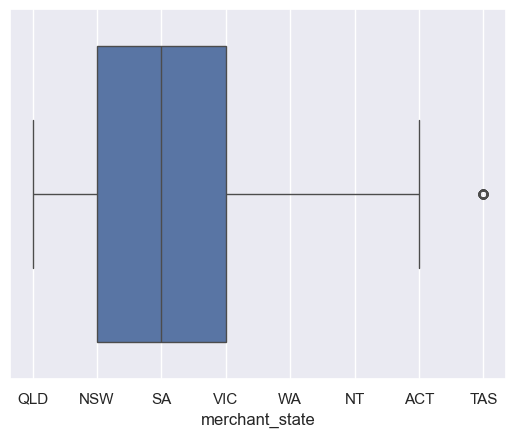

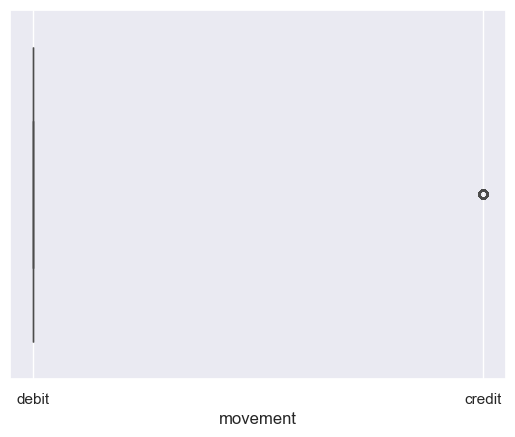

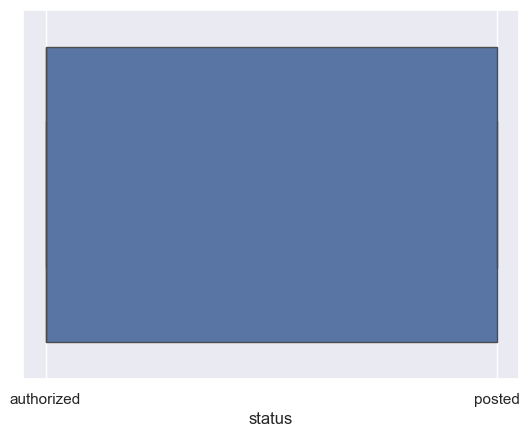

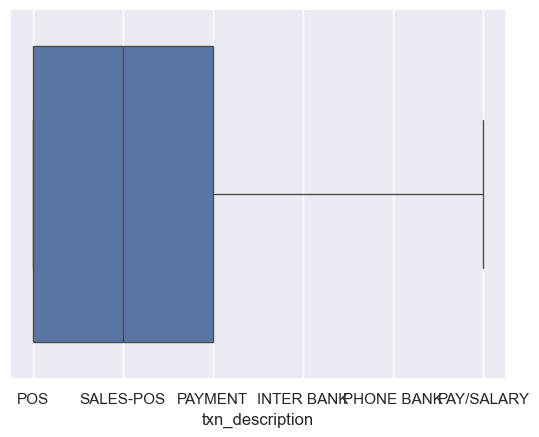

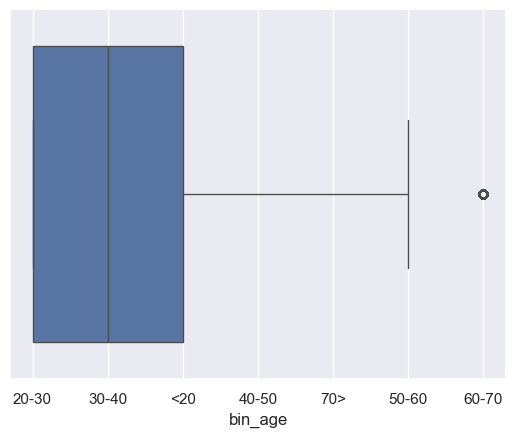

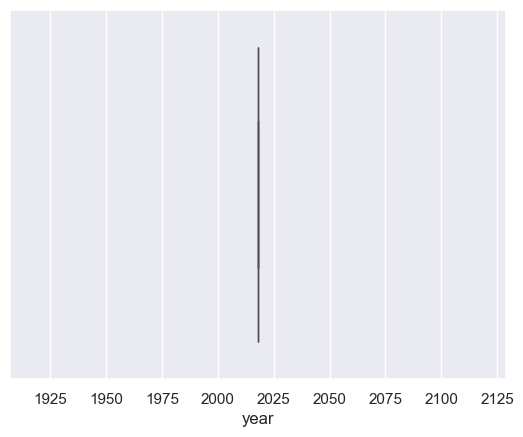

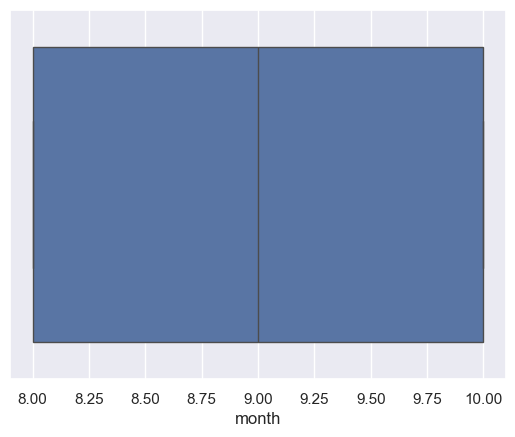

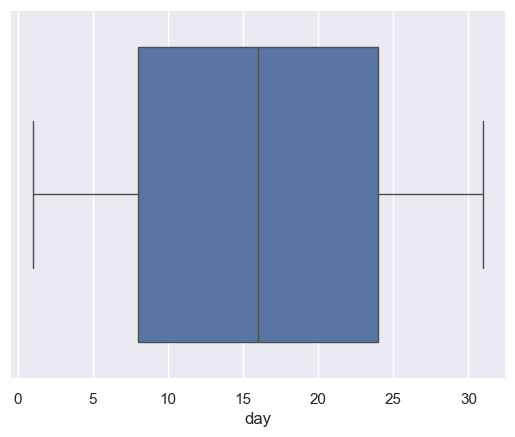

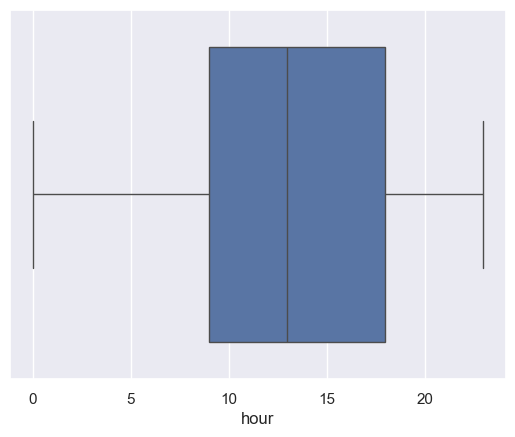

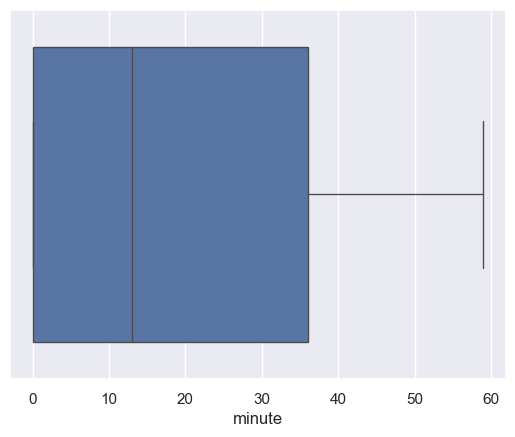

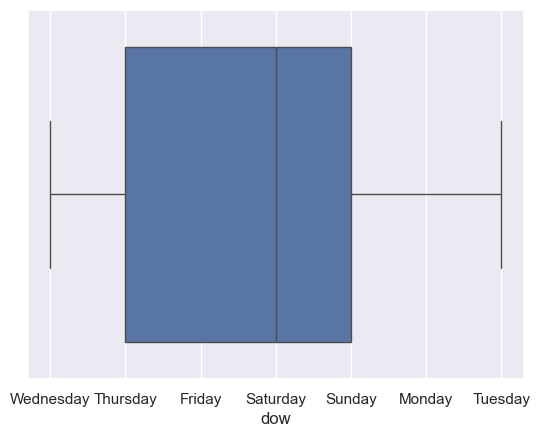

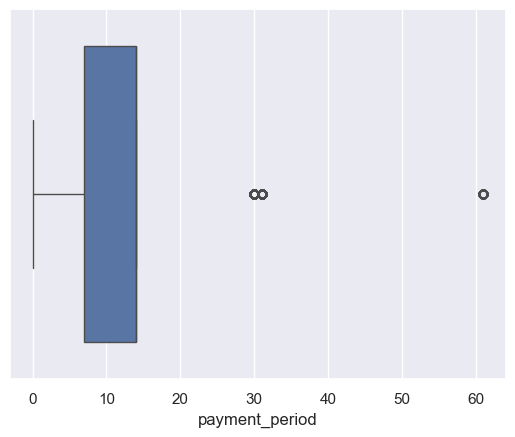

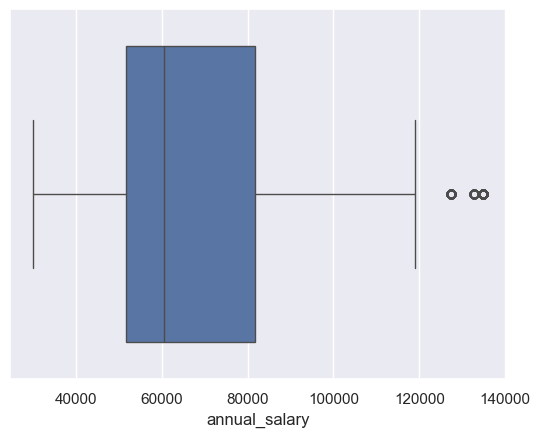

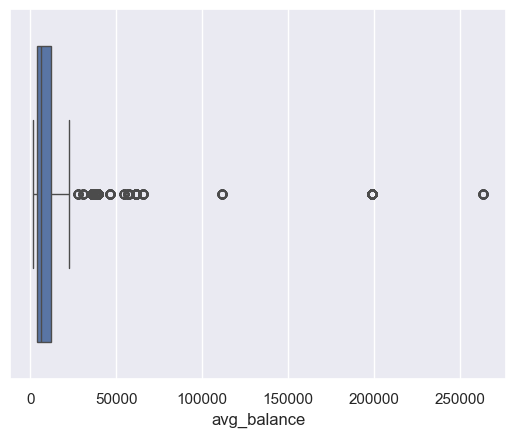

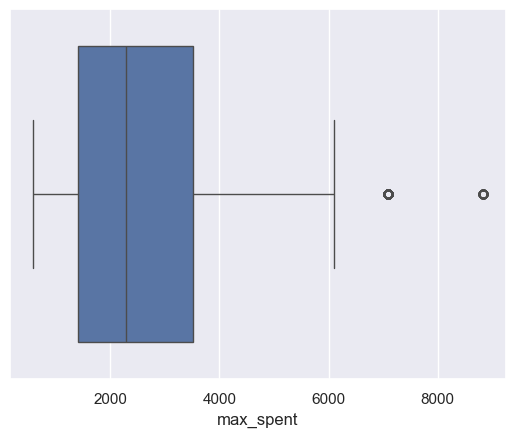

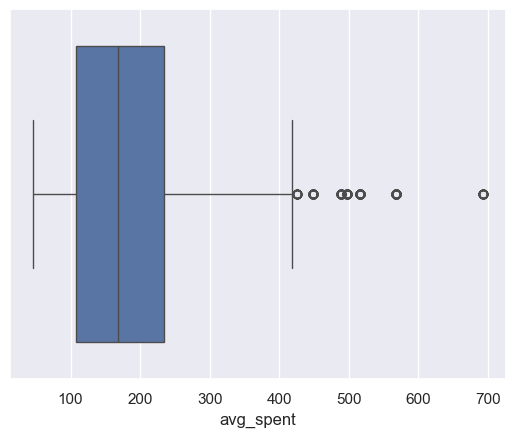

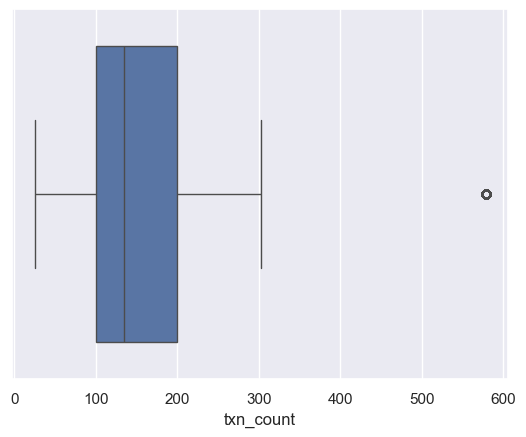

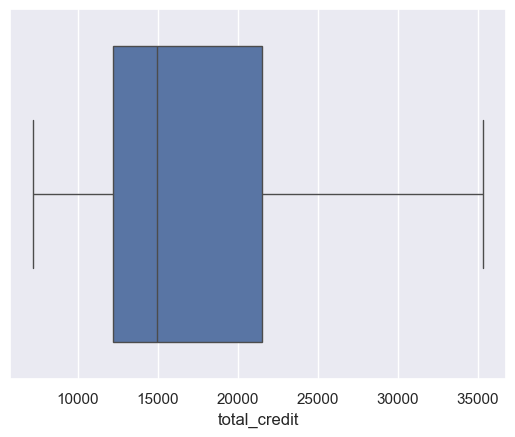

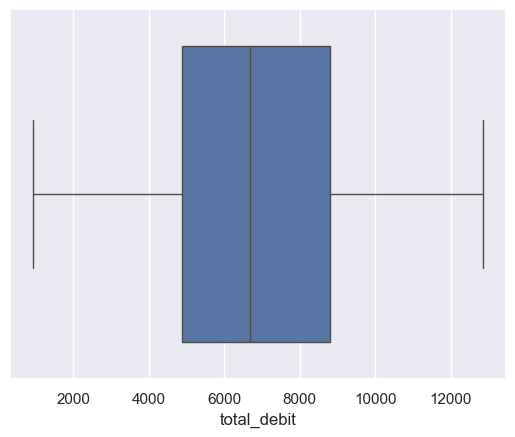

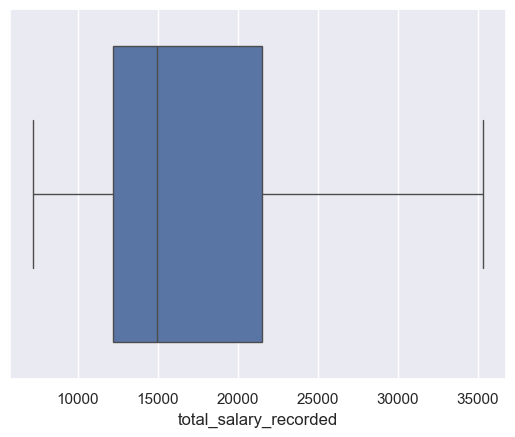

In [9]:
for i in data_linear_knn.columns:
    if data_linear_knn[i].dtypes!=object:
        sns.boxplot(data=data_linear_knn,x=data_linear_knn[i])
        plt.show()
    

In [10]:
data_linear_knn['card_present_flag'] = data_linear_knn['card_present_flag'].fillna(0)
data_linear_knn['merchant_state'] = data_linear_knn['merchant_state'].fillna(data_linear_knn['merchant_state'].mode()[0])

In [11]:
q1=data_linear_knn.quantile(0.25, numeric_only=True)
q3=data_linear_knn.quantile(0.75, numeric_only=True)
IQR=q3-q1

Lower = q1-1.5*IQR
Upper = q3+1.5*IQR

In [12]:
data_linear_knn.dtypes

age                        int64
amount                   float64
balance                  float64
card_present_flag        float64
date                         str
gender                       str
latitude                 float64
longitude                float64
merchant_state               str
movement                     str
status                       str
txn_description              str
bin_age                      str
year                       int64
month                      int64
day                        int64
hour                       int64
minute                     int64
dow                          str
payment_period             int64
annual_salary              int64
avg_balance              float64
max_spent                float64
avg_spent                float64
txn_count                  int64
total_credit             float64
total_debit              float64
total_salary_recorded    float64
dtype: object

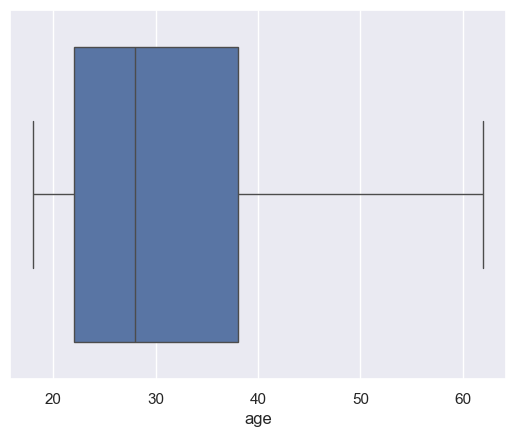

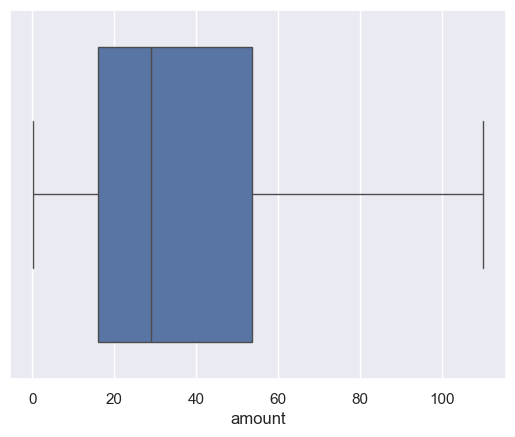

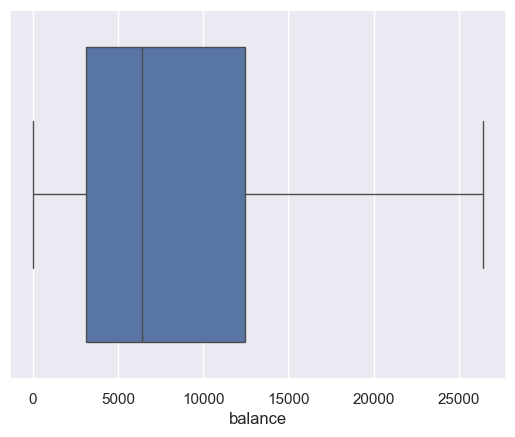

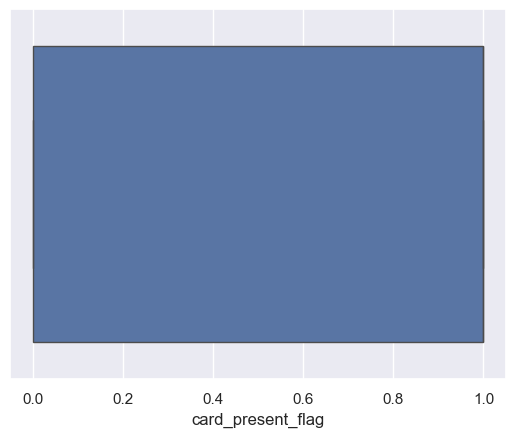

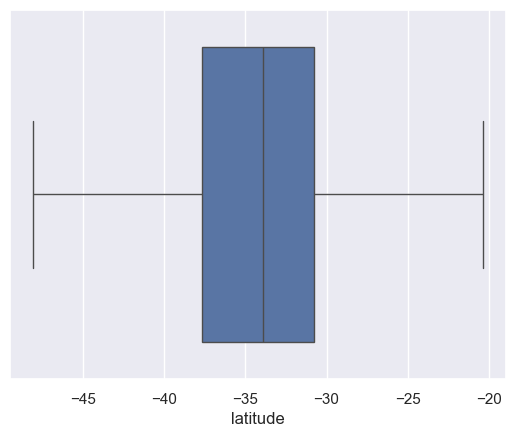

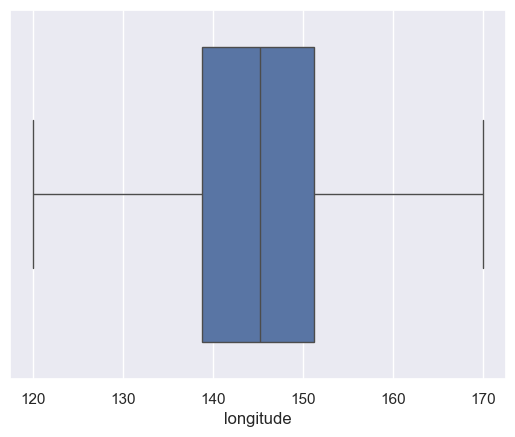

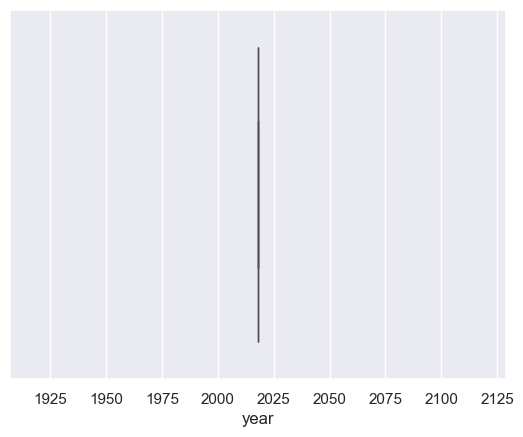

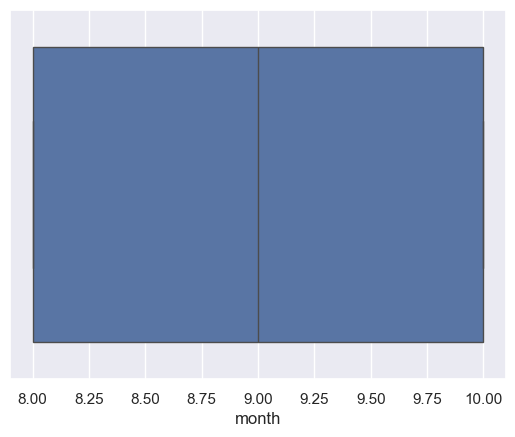

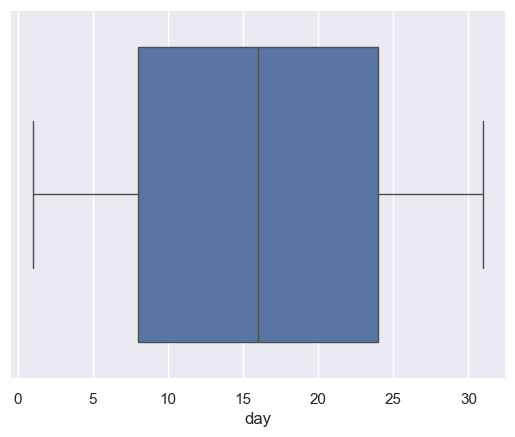

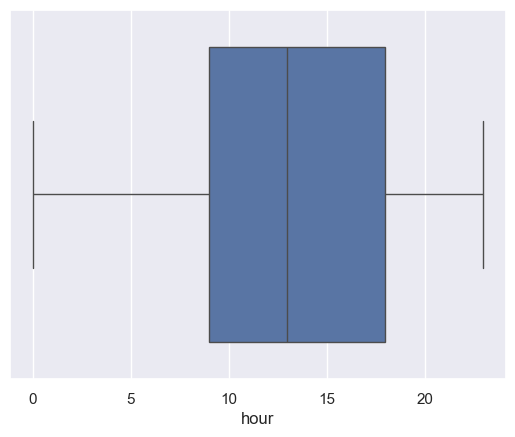

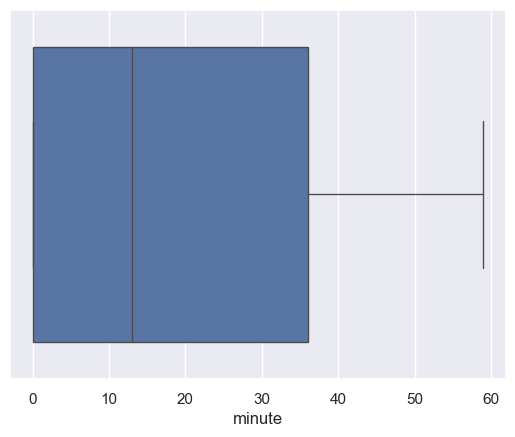

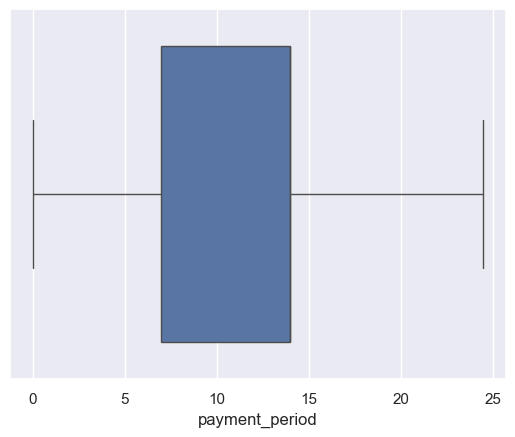

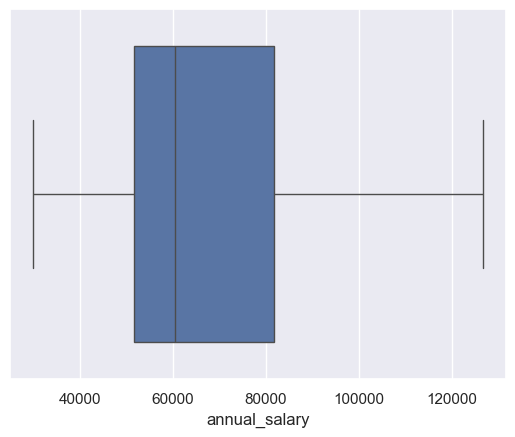

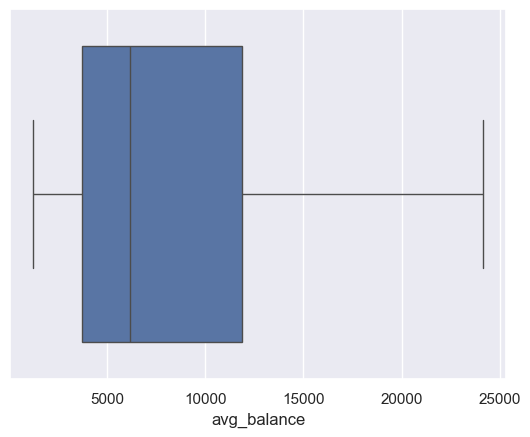

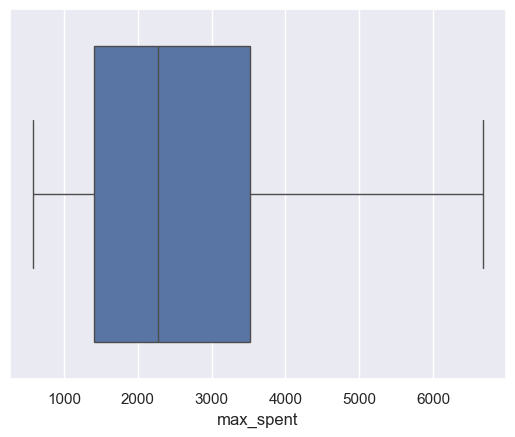

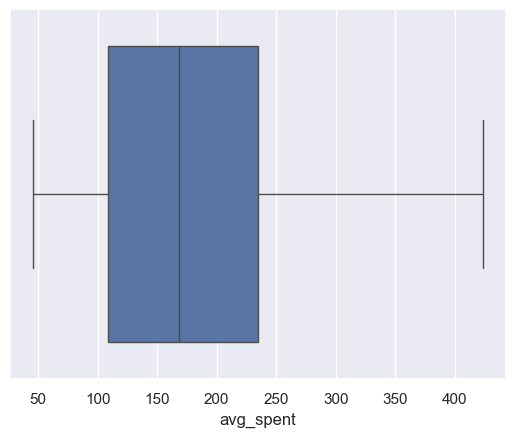

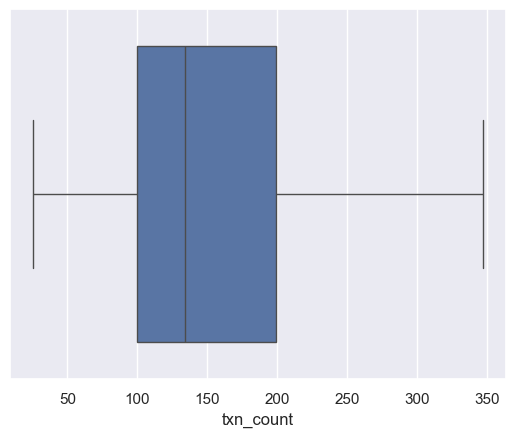

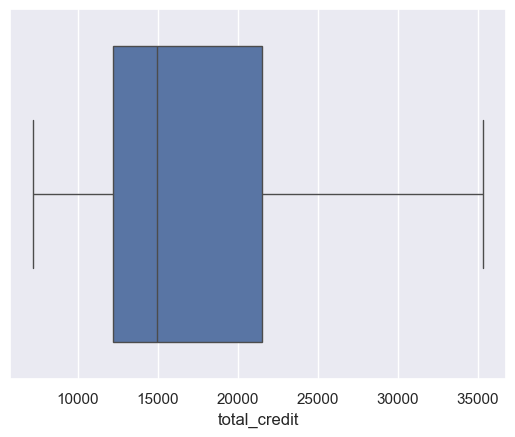

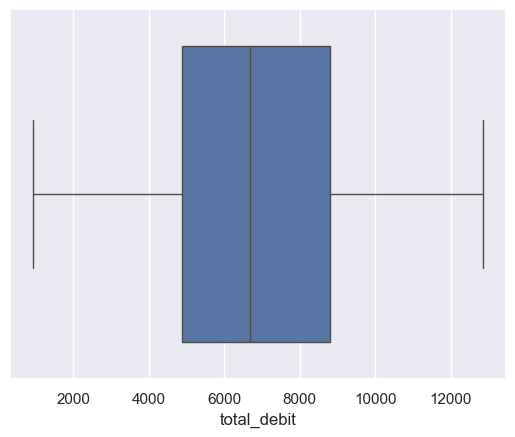

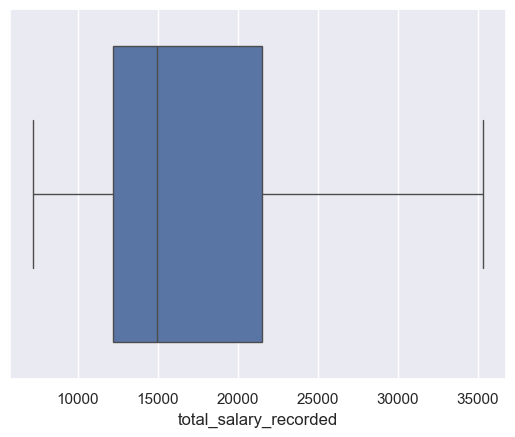

In [13]:
for i in data_linear_knn.columns:
    if pd.api.types.is_numeric_dtype(data_linear_knn[i]):
        data_linear_knn[i] = np.where(data_linear_knn[i] > Upper[i],Upper[i],data_linear_knn[i])
        data_linear_knn[i] = np.where(data_linear_knn[i] < Lower[i],Lower[i],data_linear_knn[i])
        sns.boxplot(data=data_linear_knn,x=data_linear_knn[i])
        plt.show()

In [14]:
for i in data_linear_knn.columns:
    
    if data_linear_knn[i].dtype in ['int64', 'float64']:
        
        kstest_statistic, kstest_p_value = stats.kstest(data_linear_knn[i], 'norm')
        
        
        print(f'Column: {i}')
        print(f'p-value: {kstest_p_value}')
        
        if kstest_p_value > 0.05:
            print('Data looks normally distributed')
            print()
        else:
            print('Data does not look normally distributed')
            print()

Column: age
p-value: 0.0
Data does not look normally distributed

Column: amount
p-value: 0.0
Data does not look normally distributed

Column: balance
p-value: 0.0
Data does not look normally distributed

Column: card_present_flag
p-value: 0.0
Data does not look normally distributed

Column: latitude
p-value: 0.0
Data does not look normally distributed

Column: longitude
p-value: 0.0
Data does not look normally distributed

Column: year
p-value: 0.0
Data does not look normally distributed

Column: month
p-value: 0.0
Data does not look normally distributed

Column: day
p-value: 0.0
Data does not look normally distributed

Column: hour
p-value: 0.0
Data does not look normally distributed

Column: minute
p-value: 0.0
Data does not look normally distributed

Column: payment_period
p-value: 0.0
Data does not look normally distributed

Column: annual_salary
p-value: 0.0
Data does not look normally distributed

Column: avg_balance
p-value: 0.0
Data does not look normally distributed

Column: 

In [15]:
def target_correlation(data_linear_knn, target, threshold=0.5):
    
    corr = data_linear_knn.corr(numeric_only=True, method='spearman')[target].drop(target)
    
    corr = corr[corr.abs() >= threshold]
    
    corr = corr.reindex(corr.abs().sort_values(ascending=False).index)
    
    return corr.reset_index().rename(
        columns={"index": "Variable", target: "Correlation with Target"}
    )

In [16]:
target_result = target_correlation(data_linear_knn, 'annual_salary')

target_result

,Variable,Correlation with Target
0,total_salary_recorded,0.939626
1,total_credit,0.939626
2,avg_balance,0.641721
3,max_spent,0.598184


In [17]:
def intercorrelation(data_linear_knn, target, threshold=0.7):
    
    corr_matrix = data_linear_knn.drop(columns=[target]).corr(numeric_only=True, method='spearman')
    
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    
    high_corr = corr_matrix.where(mask).stack().reset_index()
    
    high_corr.columns = ["Variable 1", "Variable 2", "Correlation"]
    
    high_corr = high_corr[high_corr["Correlation"].abs() >= threshold]
    
    return high_corr.reset_index(drop=True)

In [18]:
intercorrelated_result = intercorrelation(data_linear_knn, 'annual_salary')

intercorrelated_result

,Variable 1,Variable 2,Correlation
0,balance,avg_balance,0.834638
1,avg_spent,txn_count,-0.772005
2,txn_count,total_debit,0.744914
3,total_credit,total_salary_recorded,1.000000


In [19]:
def calculate_vif(data_linear_knn, variables):
    vif_data = data_linear_knn[variables]
    vif_values = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
    vif_result = pd.DataFrame({'VIF': vif_values, 'Features': variables})
    return vif_result


vif_result = calculate_vif(data_linear_knn, [
                                                #'total_salary_recorded', #(Random bunu chixardim chunki ikisinin de VIF-i inf gosterirdi ve target corr eyni deyerdir)
                                             'total_credit',
                                                'avg_balance',
                                        ])

vif_result

,VIF,Features
0,3.481668,total_credit
1,3.481668,avg_balance


In [20]:
cat_cols = data_linear_knn.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols

C:\Users\Asus\AppData\Local\Temp\ipykernel_9180\953736408.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data_linear_knn.select_dtypes(include=['object', 'category']).columns.tolist()


['date',
 'gender',
 'merchant_state',
 'movement',
 'status',
 'txn_description',
 'bin_age',
 'dow']

In [21]:
data_linear_knn = data_linear_knn[['date', 'gender', 'merchant_state', 'movement',
 'status', 'txn_description', 'bin_age', 'dow', 'total_credit', 'max_spent', 'avg_balance', 'annual_salary']]

In [22]:
data_linear_knn.describe(include='all')

,date,gender,merchant_state,movement,status,txn_description,bin_age,dow,total_credit,max_spent,avg_balance,annual_salary
count,12043,12043,12043,12043,12043,12043,12043,12043,12043.000000,12043.000000,12043.000000,12043.000000
unique,91,2,8,2,2,6,7,7,NaN,NaN,NaN,NaN
top,2018-09-28,M,NSW,debit,authorized,SALES-POS,20-30,Friday,NaN,NaN,NaN,NaN
freq,174,6285,6495,11160,7717,3934,5071,2073,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17175.462827,2511.432847,8941.463049,68497.053558
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6488.991783,1364.333360,6884.239858,23902.792806
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7155.960000,576.000000,1191.291419,29875.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12214.460000,1408.080000,3693.480219,51650.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14952.560000,2280.360000,6138.652540,60494.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21497.980000,3517.610000,11885.744948,81701.000000


In [23]:
for i in data_linear_knn.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data_linear_knn[i] = le.fit_transform(data_linear_knn[i])


data_linear_knn

C:\Users\Asus\AppData\Local\Temp\ipykernel_9180\1356916261.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for i in data_linear_knn.select_dtypes(include=['object']).columns:


,date,gender,merchant_state,movement,status,txn_description,bin_age,dow,total_credit,max_spent,avg_balance,annual_salary
0,0,0,3,1,0,4,0,6,14191.38,1452.21,1735.120675,52856.0
1,0,0,1,1,0,5,0,6,14191.38,1452.21,1735.120675,52856.0
2,0,0,3,1,0,5,0,6,14191.38,1452.21,1735.120675,52856.0
3,0,0,1,1,0,4,0,6,14191.38,1452.21,1735.120675,52856.0
4,0,0,3,1,0,4,0,6,14191.38,1452.21,1735.120675,52856.0
...,...,...,...,...,...,...,...,...,...,...,...,...
12038,83,0,1,0,1,1,0,6,11137.68,3712.56,4666.986795,45169.0
12039,55,0,1,0,1,1,0,6,9727.24,4863.62,4513.148800,59174.0
12040,85,0,1,0,1,1,0,0,9727.24,4863.62,4513.148800,59174.0
12041,55,1,1,0,1,1,0,6,12214.46,6107.23,3651.485473,74305.0


In [24]:
targets_lr_knn = data_linear_knn['annual_salary']

inputs_lr_knn = data_linear_knn.drop(['annual_salary'],axis=1)

In [25]:
scaler = StandardScaler()

scaler.fit(inputs_lr_knn)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [26]:
inputs_scaled_lr_knn = scaler.transform(inputs_lr_knn)

data_scaled_lr_knn = pd.DataFrame(inputs_scaled_lr_knn, columns=inputs_lr_knn.columns)

data_scaled_lr_knn

,date,gender,merchant_state,movement,status,txn_description,bin_age,dow,total_credit,max_spent,avg_balance
0,-1.726044,-1.044761,0.074589,0.281286,-0.748719,0.366190,-0.743274,1.429543,-0.459888,-0.776399,-1.046832
1,-1.726044,-1.044761,-0.793311,0.281286,-0.748719,0.997636,-0.743274,1.429543,-0.459888,-0.776399,-1.046832
2,-1.726044,-1.044761,0.074589,0.281286,-0.748719,0.997636,-0.743274,1.429543,-0.459888,-0.776399,-1.046832
3,-1.726044,-1.044761,-0.793311,0.281286,-0.748719,0.366190,-0.743274,1.429543,-0.459888,-0.776399,-1.046832
4,-1.726044,-1.044761,0.074589,0.281286,-0.748719,0.366190,-0.743274,1.429543,-0.459888,-0.776399,-1.046832
...,...,...,...,...,...,...,...,...,...,...,...
12038,1.453741,-1.044761,-0.793311,-3.555099,1.335614,-1.528149,-0.743274,1.429543,-0.930504,0.880413,-0.620933
12039,0.381042,-1.044761,-0.793311,-3.555099,1.335614,-1.528149,-0.743274,1.429543,-1.147872,1.724128,-0.643281
12040,1.530362,-1.044761,-0.793311,-3.555099,1.335614,-1.528149,-0.743274,-1.454771,-1.147872,1.724128,-0.643281
12041,0.381042,0.957157,-0.793311,-3.555099,1.335614,-1.528149,-0.743274,1.429543,-0.764558,2.635680,-0.768450


In [27]:
X_train_lr_knn, X_test_lr_knn, y_train_lr_knn, y_test_lr_knn = train_test_split(data_scaled_lr_knn, targets_lr_knn, test_size=0.2, random_state=42)

# RF Pre-processing

In [28]:
data_rf['card_present_flag'] = data_rf['card_present_flag'].fillna(0)
data_rf['merchant_state'] = data_rf['merchant_state'].fillna(data_rf['merchant_state'].mode()[0])

In [29]:
for i in data_rf.columns:
    data_rf[i] = le.fit_transform(data_rf[i])
data_rf

,age,amount,balance,card_present_flag,date,gender,latitude,longitude,merchant_state,movement,...,hour,minute,dow,payment_period,annual_salary,avg_balance,max_spent,avg_spent,txn_count,total_debit
0,8,22,6,1,0,0,70,85,2,0,...,0,1,5,1,35,1,28,0,74,96
564,18,5,1,1,0,1,41,75,0,0,...,0,17,5,1,33,0,56,3,73,93
854,20,65,61,1,0,0,72,83,2,0,...,0,24,5,1,19,8,3,1,70,79
1100,2,82,54,0,0,1,46,74,4,0,...,1,0,5,2,51,37,55,27,47,64
1223,23,76,47,1,0,0,17,31,5,0,...,1,15,5,1,40,31,10,30,48,78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10735,22,73,82,1,3,1,29,58,2,0,...,0,39,2,2,18,81,36,89,4,23
10769,28,4,68,1,3,1,62,10,0,0,...,5,22,2,2,84,64,83,92,21,50
10839,15,70,52,0,4,0,51,68,4,0,...,9,0,1,1,78,59,35,66,41,67
10944,11,69,71,0,5,1,66,12,4,0,...,2,0,4,2,92,79,92,72,48,54


In [30]:
outputs_rf = data_rf['annual_salary']

inputs_rf = data_rf.drop(['annual_salary'],axis=1)

In [31]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(inputs_rf, outputs_rf, test_size=0.2, random_state=42)

# Boosting Pre-processing

In [32]:
data_xgb_lgbm_cb.dtypes

age                    int64
amount               float64
balance              float64
card_present_flag    float64
date                     str
gender                   str
latitude             float64
longitude            float64
merchant_state           str
movement                 str
status                   str
txn_description          str
bin_age                  str
year                   int64
month                  int64
day                    int64
hour                   int64
minute                 int64
dow                      str
payment_period         int64
annual_salary          int64
avg_balance          float64
max_spent            float64
avg_spent            float64
txn_count              int64
total_debit          float64
dtype: object

In [33]:
encoders = {}
for i in data_xgb_lgbm_cb.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data_xgb_lgbm_cb[i] = le.fit_transform(data_xgb_lgbm_cb[i])
    encoders[i] = le

C:\Users\Asus\AppData\Local\Temp\ipykernel_9180\2795007443.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for i in data_xgb_lgbm_cb.select_dtypes(include=['object']).columns:


In [34]:
data_xgb_lgbm_cb.describe(include='all').transpose()

,count,mean,std,min,25%,50%,75%,max
age,100.0,31.770000,11.544254,18.000000,22.000000,29.500000,39.250000,78.000000
amount,100.0,55.903200,170.255646,3.280000,18.772500,28.755000,41.910000,1692.560000
balance,100.0,12270.925000,34893.509619,2.850000,292.297500,1608.615000,5816.835000,260514.830000
card_present_flag,100.0,0.500000,0.502519,0.000000,0.000000,0.500000,1.000000,1.000000
date,100.0,0.510000,1.010001,0.000000,0.000000,0.000000,1.000000,6.000000
gender,100.0,0.560000,0.498888,0.000000,0.000000,1.000000,1.000000,1.000000
latitude,100.0,-38.647500,54.272929,-573.000000,-37.760000,-33.975000,-31.895000,-12.370000
longitude,100.0,143.565800,16.194410,114.620000,143.565000,145.155000,150.905000,255.000000
merchant_state,100.0,3.270000,1.937691,0.000000,2.000000,4.000000,5.000000,6.000000
movement,100.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [35]:
outputs_xgb_lgbm_cb = data_xgb_lgbm_cb['annual_salary']

inputs_xgb_lgbm_cb = data_xgb_lgbm_cb.drop(['annual_salary'],axis=1)

In [36]:
outputs_cat_trees = data_cat_trees['annual_salary']

inputs_cat_trees = data_cat_trees.drop(['annual_salary'],axis=1)

In [37]:
X_train_xgb_lgbm_cb, X_test_xgb_lgbm_cb, y_train_xgb_lgbm_cb, y_test_xgb_lgbm_cb = train_test_split(inputs_xgb_lgbm_cb, outputs_xgb_lgbm_cb, test_size=0.2, random_state=42)

In [38]:
X_train_cat_trees, X_test_cat_trees, y_train_cat_trees, y_test_cat_trees = train_test_split(inputs_cat_trees, outputs_cat_trees, test_size=0.2, random_state=42)

# Modelling

In [39]:
def train_and_evaluate_model(model_name, model, X_train, y_train, X_test, y_test):
    try:
        model.fit(X_train, y_train)

        y_pred_train = model.predict(X_train)

        mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
        mse_train = metrics.mean_squared_error(y_train, y_pred_train)
        rmse_train = np.sqrt(mse_train)
        r2_train = metrics.r2_score(y_train, y_pred_train)

        print(f'Model Performance for {model_name}')
        print('Train R2 value is', r2_train)


        y_pred_test = model.predict(X_test)
        #y_prob_test = model.predict_proba(X_test)[:, 1]

        mae_test = metrics.mean_absolute_error(y_test, y_pred_test)
        mse_test = metrics.mean_squared_error(y_test, y_pred_test)
        rmse_test = np.sqrt(mse_test)
        r2_test = metrics.r2_score(y_test, y_pred_test)

        print(f'Model Performance for {model_name}')
        print('Test R2 value is', r2_test)


        return [r2_train, r2_test]

    except Exception as e:
        print(f"An error occurred while evaluating the model {model_name}: {e}")
        return None

In [40]:
models = []

lr_model = LinearRegression()
knn_model_def = KNeighborsRegressor()
rf_model_def = RandomForestRegressor(random_state=42)
xgb_model_def = XGBRegressor(random_state=42)
lgb_model_def = LGBMRegressor(random_state=42)
catboost_model_def = CatBoostRegressor(random_state=42)
catboost_model_custom = CatBoostRegressor(cat_features=['date', 'gender', 'merchant_state', 'movement', 'status',
                                                             'txn_description', 'bin_age', 'dow'], random_state=42)

models.extend([
    ('LR', lr_model),
    ('KNN', knn_model_def),
    ('RF', rf_model_def),
    ('XGBoost', xgb_model_def),
    ('LightGBM', lgb_model_def),
    ('CatBoost', catboost_model_def),
    ('CatBoost_Custom', catboost_model_custom)
])

In [41]:
r2_df = pd.DataFrame(columns=['Model', 'Train R2', 'Test R2'])

for model_name, model in models:
    if model_name == 'CatBoost_Custom':
        r2_pred = train_and_evaluate_model(model_name, model, X_train_cat_trees, y_train_cat_trees, X_test_cat_trees, y_test_cat_trees)
    elif model_name == 'LR' or model_name == 'KNN':
        r2_pred = train_and_evaluate_model(model_name, model, X_train_lr_knn, y_train_lr_knn, X_test_lr_knn, y_test_lr_knn)
    elif model_name == 'RF':
        r2_pred = train_and_evaluate_model(model_name, model, X_train_rf, y_train_rf, X_test_rf, y_test_rf)
    else:
        r2_pred = train_and_evaluate_model(model_name, model, X_train_xgb_lgbm_cb, y_train_xgb_lgbm_cb, X_test_xgb_lgbm_cb, y_test_xgb_lgbm_cb)

    if r2_pred is not None:
        r2_df = pd.concat([r2_df, pd.DataFrame({'Model': [model_name], 'Train R2': [r2_pred[0]], 'Test R2': [r2_pred[1]]})], ignore_index=True)

r2_df_sorted = r2_df.sort_values(by='Test R2', ascending=False)

r2_df_sorted

Model Performance for LR
Train R2 value is 0.9449737877196394
Model Performance for LR
Test R2 value is 0.946642286814687
Model Performance for KNN
Train R2 value is 0.9870166444774675
Model Performance for KNN
Test R2 value is 0.9788816694902122
Model Performance for RF
Train R2 value is 0.9445174208512294
Model Performance for RF
Test R2 value is 0.4203619760758316
Model Performance for XGBoost
Train R2 value is 1.0
Model Performance for XGBoost
Test R2 value is 0.46576303243637085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 336
[LightGBM] [Info] Number of data points in the train set: 80, number of used features: 22
[LightGBM] [Info] Start training from score 67853.350000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

,Model,Train R2,Test R2
1,KNN,0.987017,0.978882
0,LR,0.944974,0.946642
4,LightGBM,0.922856,0.676606
5,CatBoost,0.999997,0.568348
6,CatBoost_Custom,0.985768,0.561163
3,XGBoost,1.0,0.465763
2,RF,0.944517,0.420362


In [42]:
r2_df_sorted

,Model,Train R2,Test R2
1,KNN,0.987017,0.978882
0,LR,0.944974,0.946642
4,LightGBM,0.922856,0.676606
5,CatBoost,0.999997,0.568348
6,CatBoost_Custom,0.985768,0.561163
3,XGBoost,1.0,0.465763
2,RF,0.944517,0.420362


# Optimization

In [43]:
def best_params_for_model(trial):
    param = {
    'n_neighbors': trial.suggest_int('n_neighbors', 1, 50), 
    'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),  
    'algorithm': trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute']),  
    'leaf_size': trial.suggest_int('leaf_size', 10, 100),  
    'p': trial.suggest_int('p', 1, 2),  
    'metric': trial.suggest_categorical('metric', ['minkowski', 'euclidean', 'manhattan']) 
}

    knn_reg = KNeighborsRegressor(**param)

    r2 = cross_val_score(knn_reg, X_train_lr_knn, y_train_lr_knn, cv=5, scoring='r2', n_jobs=-1).mean()
    return r2

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=5)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_knn_model = KNeighborsRegressor(**best_params)

[I 2026-03-30 11:33:31,541] A new study created in memory with name: no-name-e7776a48-49a9-4278-88c8-baedfd9dbf27
[I 2026-03-30 11:33:38,046] Trial 0 finished with value: 0.9921389962070275 and parameters: {'n_neighbors': 2, 'weights': 'distance', 'algorithm': 'auto', 'leaf_size': 35, 'p': 1, 'metric': 'minkowski'}. Best is trial 0 with value: 0.9921389962070275.
[I 2026-03-30 11:33:43,183] Trial 1 finished with value: 0.9771747097382584 and parameters: {'n_neighbors': 3, 'weights': 'uniform', 'algorithm': 'brute', 'leaf_size': 33, 'p': 2, 'metric': 'minkowski'}. Best is trial 0 with value: 0.9921389962070275.
[I 2026-03-30 11:33:43,968] Trial 2 finished with value: 0.9674255846203781 and parameters: {'n_neighbors': 27, 'weights': 'uniform', 'algorithm': 'auto', 'leaf_size': 88, 'p': 1, 'metric': 'minkowski'}. Best is trial 0 with value: 0.9921389962070275.
[I 2026-03-30 11:33:44,671] Trial 3 finished with value: 0.9565697532977708 and parameters: {'n_neighbors': 32, 'weights': 'distan

Best trial:
  Value: 0.992
  Params:  {'n_neighbors': 2, 'weights': 'distance', 'algorithm': 'auto', 'leaf_size': 35, 'p': 1, 'metric': 'minkowski'}


In [44]:
def best_params_for_model(trial):
    param = {
    'n_estimators': trial.suggest_int('n_estimators', 200, 1000), 
    'max_features': trial.suggest_float('max_features', 0.3, 0.5),  
    'max_depth': trial.suggest_int('max_depth', 10, 100),  
    'min_samples_split': trial.suggest_int('min_samples_split', 20, 50),  
    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 10),
}

    rf_reg = RandomForestRegressor(**param, random_state=42)

    r2 = cross_val_score(rf_reg, X_train_rf, y_train_rf, cv=5, scoring='r2', n_jobs=-1).mean()
    return r2

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=20)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_rf_model = RandomForestRegressor(**best_params, random_state=42)

[I 2026-03-30 11:33:45,112] A new study created in memory with name: no-name-57528b7f-01c3-4f6f-9d69-6cdcf1f62621
[I 2026-03-30 11:33:47,846] Trial 0 finished with value: 0.34852109572630474 and parameters: {'n_estimators': 727, 'max_features': 0.40581795951756083, 'max_depth': 67, 'min_samples_split': 33, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.34852109572630474.
[I 2026-03-30 11:33:48,839] Trial 1 finished with value: 0.3509876270652726 and parameters: {'n_estimators': 265, 'max_features': 0.44343261858328875, 'max_depth': 85, 'min_samples_split': 36, 'min_samples_leaf': 9}. Best is trial 1 with value: 0.3509876270652726.
[I 2026-03-30 11:33:49,699] Trial 2 finished with value: 0.28159574625642375 and parameters: {'n_estimators': 244, 'max_features': 0.49840020475212327, 'max_depth': 92, 'min_samples_split': 40, 'min_samples_leaf': 6}. Best is trial 1 with value: 0.3509876270652726.
[I 2026-03-30 11:33:50,851] Trial 3 finished with value: 0.25323537330540147 and parame

Best trial:
  Value: 0.468
  Params:  {'n_estimators': 988, 'max_features': 0.3604420302828221, 'max_depth': 11, 'min_samples_split': 20, 'min_samples_leaf': 5}


In [45]:
def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100)
    }

    lgb_reg = LGBMRegressor(**param)

    r2 = cross_val_score(lgb_reg, X_train_xgb_lgbm_cb, y_train_xgb_lgbm_cb, cv=3, scoring='r2', n_jobs=-1).mean()
    return r2

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=5)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_lgb_model = LGBMRegressor(**best_params)

[I 2026-03-30 11:34:25,645] A new study created in memory with name: no-name-21dca3d4-e2a1-40e0-8282-f052e106b353
C:\Users\Asus\AppData\Local\Temp\ipykernel_9180\1301780115.py:4: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
[I 2026-03-30 11:34:28,695] Trial 0 finished with value: 0.4261911249392784 and parameters: {'n_estimators': 832, 'learning_rate': 0.24459306847174078, 'max_depth': 6, 'num_leaves': 82}. Best is trial 0 with value: 0.4261911249392784.
[I 2026-03-30 11:34:31,311] Trial 1 finished with value: 0.6160950590600556 and parameters: {'n_estimators': 412, 'learning_rate': 0.026462032270527205, 'max_depth': 7, 'num_leaves': 28}. Best is trial 1 with value: 0.6160950590600556.
[I 2026-03-30 11:34:33,783] Trial 2 finished with value: 0.6235321822438

Best trial:
  Value: 0.624
  Params:  {'n_estimators': 249, 'learning_rate': 0.12225363077516184, 'max_depth': 5, 'num_leaves': 22}


In [46]:
def best_params_for_model(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
         # Fraction of the training data to be randomly sampled for each boosting round (to reduce overfitting)
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        # Fraction of features (columns) to be randomly sampled for each tree (adds diversity)
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        # Controls how much gain is needed to make a split; higher = fewer splits (simpler model)
        'gamma': trial.suggest_int('gamma', 0, 10)
    }

    xgb_reg = XGBRegressor(**param)
    r2 = cross_val_score(xgb_reg, X_train_xgb_lgbm_cb, y_train_xgb_lgbm_cb, cv=3, scoring='r2', n_jobs=-1).mean()
    return r2



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=10)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_xgb_model = XGBRegressor(**best_params)

[I 2026-03-30 11:34:34,533] A new study created in memory with name: no-name-2a5a35c8-98e0-431c-b295-d5f12543f70f
[I 2026-03-30 11:34:35,104] Trial 0 finished with value: 0.6437297264734904 and parameters: {'n_estimators': 154, 'learning_rate': 0.10804616264070867, 'max_depth': 5, 'subsample': 0.544905171165113, 'colsample_bytree': 0.7605360558951018, 'gamma': 6}. Best is trial 0 with value: 0.6437297264734904.
[I 2026-03-30 11:34:35,942] Trial 1 finished with value: 0.4885026812553406 and parameters: {'n_estimators': 494, 'learning_rate': 0.3306647828517452, 'max_depth': 4, 'subsample': 0.5930804997455041, 'colsample_bytree': 0.5675073394681215, 'gamma': 9}. Best is trial 0 with value: 0.6437297264734904.
[I 2026-03-30 11:34:38,451] Trial 2 finished with value: 0.6727566520373026 and parameters: {'n_estimators': 909, 'learning_rate': 0.02713719161167779, 'max_depth': 8, 'subsample': 0.7130821458906889, 'colsample_bytree': 0.556969858160832, 'gamma': 10}. Best is trial 2 with value: 0.

Best trial:
  Value: 0.677
  Params:  {'n_estimators': 431, 'learning_rate': 0.019192307040595345, 'max_depth': 9, 'subsample': 0.5698380398134059, 'colsample_bytree': 0.5245971935631661, 'gamma': 10}


In [47]:
def best_params_for_model(trial):

    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), # Regularization term that prevents overfitting by penalizing large parameter values.
        # 'cat_features': [],  # Handle categorical features separately
        'loss_function': trial.suggest_categorical('loss_function', ['RMSE']) # For regression tasks, use ‘RMSE,’ while for classification, use ‘Logloss’.
    }

    cb_reg = CatBoostRegressor(**param)

    r2 = cross_val_score(cb_reg, X_train_xgb_lgbm_cb, y_train_xgb_lgbm_cb, cv=3, scoring='r2', n_jobs=-1).mean()
    return r2



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=5)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_cb_model = CatBoostRegressor(**best_params)

[I 2026-03-30 11:34:42,874] A new study created in memory with name: no-name-ffbf1354-54f0-464c-a75e-a84a5205c950
C:\Users\Asus\AppData\Local\Temp\ipykernel_9180\3163203743.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
C:\Users\Asus\AppData\Local\Temp\ipykernel_9180\3163203743.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), # Regularization term that prevents overfitting by penalizing large parameter values.
[I 2026-03-30 11:34:45,579] Trial 0 finished with value: 0.7044327403784525 and parameters: {'iterations': 698, 'learnin

Best trial:
  Value: 0.704
  Params:  {'iterations': 698, 'learning_rate': 0.01889333450428244, 'depth': 5, 'l2_leaf_reg': 6.761819331261784, 'loss_function': 'RMSE'}


In [48]:
def best_params_for_model(trial):

    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), # Regularization term that prevents overfitting by penalizing large parameter values.
        #'cat_features': ['date', 'gender', 'merchant_state', 'movement', 'status', 'txn_description', 'bin_age', 'dow'],  # Handle categorical features separately
        'loss_function': trial.suggest_categorical('loss_function', ['RMSE']) # For regression tasks, use ‘RMSE,’ while for classification, use ‘Logloss’.
    }
    
    cats = ['date', 'gender', 'merchant_state', 'movement', 'status', 'txn_description', 'bin_age', 'dow']

    cb_custom_reg = CatBoostRegressor(**param)

    r2 = cross_val_score(cb_custom_reg, X_train_cat_trees, y_train_cat_trees, cv=3, scoring='r2', n_jobs=-1, params={'cat_features': cats}).mean()
    return r2



study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=5)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_cb_custom_model = CatBoostRegressor(**best_params)
best_cb_custom_model.fit(X_train_cat_trees, y_train_cat_trees, 
                         cat_features=['date', 'gender', 'merchant_state', 'movement', 'status', 'txn_description', 'bin_age', 'dow'])

[I 2026-03-30 11:35:08,359] A new study created in memory with name: no-name-a78bcab2-86f6-4b33-a901-39be6337ecdf
C:\Users\Asus\AppData\Local\Temp\ipykernel_9180\1067720447.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 1.0),
C:\Users\Asus\AppData\Local\Temp\ipykernel_9180\1067720447.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 0.1, 10), # Regularization term that prevents overfitting by penalizing large parameter values.
[I 2026-03-30 11:35:37,770] Trial 0 finished with value: 0.5444483863379672 and parameters: {'iterations': 713, 'learnin

Best trial:
  Value: 0.632
  Params:  {'iterations': 886, 'learning_rate': 0.05749093373499162, 'depth': 5, 'l2_leaf_reg': 0.43255971347324046, 'loss_function': 'RMSE'}
0:	learn: 24073.4171924	total: 339ms	remaining: 5m
1:	learn: 23434.9143884	total: 457ms	remaining: 3m 21s
2:	learn: 22671.2652916	total: 557ms	remaining: 2m 43s
3:	learn: 22057.7416575	total: 702ms	remaining: 2m 34s
4:	learn: 21295.6279315	total: 803ms	remaining: 2m 21s
5:	learn: 20833.7227688	total: 881ms	remaining: 2m 9s
6:	learn: 20207.7146097	total: 956ms	remaining: 2m
7:	learn: 19649.5794009	total: 1.03s	remaining: 1m 52s
8:	learn: 19079.9857333	total: 1.1s	remaining: 1m 47s
9:	learn: 18483.0312509	total: 1.18s	remaining: 1m 43s
10:	learn: 17975.1419550	total: 1.26s	remaining: 1m 39s
11:	learn: 17414.8191753	total: 1.34s	remaining: 1m 37s
12:	learn: 16963.4858999	total: 1.42s	remaining: 1m 35s
13:	learn: 16485.9921150	total: 1.49s	remaining: 1m 32s
14:	learn: 16072.2880168	total: 1.56s	remaining: 1m 30s
15:	learn: 

CatBoostRegressor(depth=5, iterations=886, l2_leaf_reg=0.43255971347324046, learning_rate=0.05749093373499162, loss_function='RMSE')

In [49]:
models_optimized = []

models_optimized.extend([
    ('KNN Optuna', best_knn_model),
    ('RF Optuna', best_rf_model),
    ('XGBoost Optuna', best_xgb_model),
    ('LightGBM Optuna', best_lgb_model),
    ('CatBoost Optuna', best_cb_model),
    ('CatBoost_Custom Optuna', best_cb_custom_model)
])

In [50]:
r2_df_optuna = pd.DataFrame(columns=['Model', 'Train R2', 'Test R2'])

for model_name, model in models_optimized:
    if model_name == 'CatBoost_Custom Optuna':
        r2_pred = train_and_evaluate_model(model_name, model, X_train_cat_trees, y_train_cat_trees, X_test_cat_trees, y_test_cat_trees)
    elif model_name == 'KNN Optuna':
        r2_pred = train_and_evaluate_model(model_name, model, X_train_lr_knn, y_train_lr_knn, X_test_lr_knn, y_test_lr_knn)
    elif model_name == 'RF Optuna':
        r2_pred = train_and_evaluate_model(model_name, model, X_train_rf, y_train_rf, X_test_rf, y_test_rf)
    else:
        r2_pred = train_and_evaluate_model(model_name, model, X_train_xgb_lgbm_cb, y_train_xgb_lgbm_cb, X_test_xgb_lgbm_cb, y_test_xgb_lgbm_cb)

    if r2_pred is not None:
        r2_df_optuna = pd.concat([r2_df_optuna, pd.DataFrame({'Model': [model_name], 'Train R2': [r2_pred[0]], 'Test R2': [r2_pred[1]]})], ignore_index=True)

r2_df_sorted_optuna = r2_df_optuna.sort_values(by='Test R2', ascending=False)

r2_df_sorted_optuna

Model Performance for KNN Optuna
Train R2 value is 1.0
Model Performance for KNN Optuna
Test R2 value is 0.9950901838712168
Model Performance for RF Optuna
Train R2 value is 0.7063593084369106
Model Performance for RF Optuna
Test R2 value is 0.49705719659964076
Model Performance for XGBoost Optuna
Train R2 value is 0.9983848333358765
Model Performance for XGBoost Optuna
Test R2 value is 0.5316718816757202
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 336
[LightGBM] [Info] Number of data points in the train set: 80, number of used features: 22
[LightGBM] [Info] Start training from score 67853.350000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

,Model,Train R2,Test R2
0,KNN Optuna,1.0,0.99509
3,LightGBM Optuna,0.976077,0.684948
4,CatBoost Optuna,0.993476,0.566276
2,XGBoost Optuna,0.998385,0.531672
1,RF Optuna,0.706359,0.497057


In [51]:
final_review = pd.concat([r2_df_sorted,r2_df_sorted_optuna], axis=0)

final_review_sorted = final_review.sort_values(by='Test R2', ascending=False)
final_review_sorted.reset_index(drop=True, inplace=True)

final_review_sorted

,Model,Train R2,Test R2
0,KNN Optuna,1.0,0.99509
1,KNN,0.987017,0.978882
2,LR,0.944974,0.946642
3,LightGBM Optuna,0.976077,0.684948
4,LightGBM,0.922856,0.676606
5,CatBoost,0.999997,0.568348
6,CatBoost Optuna,0.993476,0.566276
7,CatBoost_Custom,0.985768,0.561163
8,XGBoost Optuna,0.998385,0.531672
9,RF Optuna,0.706359,0.497057


In [52]:
final_review_sorted['R2_gap'] = (final_review_sorted['Train R2'] - final_review_sorted['Test R2']).abs()

final_review_sorted = final_review_sorted.sort_values(
    by=['Test R2', 'R2_gap'],
    ascending=[False, True]
).reset_index(drop=True)

final_review_sorted

,Model,Train R2,Test R2,R2_gap
0,KNN Optuna,1.0,0.99509,0.00491
1,KNN,0.987017,0.978882,0.008135
2,LR,0.944974,0.946642,0.001668
3,LightGBM Optuna,0.976077,0.684948,0.291129
4,LightGBM,0.922856,0.676606,0.24625
5,CatBoost,0.999997,0.568348,0.431649
6,CatBoost Optuna,0.993476,0.566276,0.4272
7,CatBoost_Custom,0.985768,0.561163,0.424605
8,XGBoost Optuna,0.998385,0.531672,0.466713
9,RF Optuna,0.706359,0.497057,0.209302


### Univariate

In [56]:
results = []

for i in X_train_lr_knn.columns: 
    X_train_single_var = X_train_lr_knn[[i]]
    X_test_single_var = X_test_lr_knn[[i]]

    lr_model.fit(X_train_single_var, y_train_lr_knn)
    
    y_pred_train_single_var = lr_model.predict(X_train_single_var)

    train_r2 = metrics.r2_score(y_train_lr_knn, y_pred_train_single_var)

    y_pred_test_single_var = lr_model.predict(X_test_single_var)

    test_r2 = metrics.r2_score(y_test_lr_knn, y_pred_test_single_var)

    results.append({'Variable': i, 'Train R2': train_r2, 'Test R2': test_r2})

results_df = pd.DataFrame(results)

results_df_sorted = results_df.sort_values(by='Test R2', ascending=False)

results_df_sorted

,Variable,Train R2,Test R2
8,total_credit,0.930178,0.926929
9,max_spent,0.272809,0.290008
10,avg_balance,0.276472,0.257650
4,status,0.023412,0.020173
5,txn_description,0.021126,0.017372
2,merchant_state,0.010698,0.012167
1,gender,0.012181,0.009765
6,bin_age,0.001718,0.000727
7,dow,0.000304,-0.000458
0,date,0.000130,-0.000775


In [57]:
inputs_lr_uni = data_scaled_lr_knn[['total_credit', 'max_spent','avg_balance']]

In [58]:
X_train_uni, X_test_uni, y_train_uni, y_test_uni = train_test_split(inputs_lr_uni, targets_lr_knn, test_size=0.2, random_state=42)

In [59]:
lr_model_uni = LinearRegression()
lr_model_uni.fit(X_train_uni,y_train_uni)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [62]:
y_pred_uni = lr_model_uni.predict(X_test_uni)
y_pred_train_uni = lr_model_uni.predict(X_train_uni)

In [67]:
mae_test = metrics.mean_absolute_error(y_test_uni, y_pred_uni)
mse_test = metrics.mean_squared_error(y_test_uni, y_pred_uni)
rmse_test = np.sqrt(mse_test)
r2_test = metrics.r2_score(y_test_uni, y_pred_uni)

mae_train = metrics.mean_absolute_error(y_train_uni, y_pred_train_uni)
mse_train = metrics.mean_squared_error(y_train_uni, y_pred_train_uni)
rmse_train = np.sqrt(mse_train)
r2_train = metrics.r2_score(y_train_uni, y_pred_train_uni)

def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

n_train = len(y_train_uni)
n_test = len(y_test_uni)
k = X_train_uni.shape[1]

adj_r2_train = adjusted_r2(r2_train, n_train, k)
adj_r2_test = adjusted_r2(r2_test, n_test, k)


# Results summary
results_dict = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2', 'Adjusted R2'],
    'Train': [mae_train, mse_train, rmse_train, r2_train, adj_r2_train],
    'Test': [mae_test, mse_test, rmse_test, r2_test, adj_r2_test]
}

results_df = pd.DataFrame(results_dict)

results_df.style.format({
    'Train': '{:.3f}',
    'Test': '{:.3f}'
})

,Metric,Train,Test
0,MAE,4029.364,3976.791
1,MSE,32162707.245,31008564.321
2,RMSE,5671.217,5568.533
3,R2,0.944,0.945
4,Adjusted R2,0.944,0.945
